<a href="https://www.kaggle.com/code/avikdas567/cuhk-x-large-model-track-multi-task-pipeline?scriptVersionId=332353771" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# CUHK-X Competition: Large Model Track - Advanced Multi-Task Deep Learning Pipeline

This notebook delivers a comprehensive, end-to-end engineering solution designed to address the Human Action Understanding (HAU) and Human Action Reasoning (HARn) challenges. The methodology optimizes performance using text and metadata context, applying a robust Multi-Head Deep Learning Architecture accelerated via a Dual T4 GPU configuration.

## Pipeline Strategy Overview
* **Exploratory Data Analysis**: Visualizing distribution imbalances across task structures and benchmark sources.
* **Feature Engineering**: Structured context prompt compilation incorporating question categories and multi-choice variations.
* **Model Architecture**: Multi-head PyTorch neural network that treats single-choice as classification, multi-choice as multi-label binary classification, and temporal sequences as an exact 24-permutation class problem.
* **Hardware Optimization**: High-throughput distributed processing across Dual T4 GPUs utilizing automatic mixed precision.

In [1]:
import os
import random
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
from transformers import AutoTokenizer, AutoModel

import warnings
warnings.filterwarnings('ignore')

print("Libraries successfully imported. PyTorch version:", torch.__version__)

Libraries successfully imported. PyTorch version: 2.10.0+cu128


# Core Environment and Global Seed Initialization

Deterministic execution is enforced to ensure complete reproducibility of all validation metrics, out-of-fold scores, and model weights across subsequent notebook executions.

In [2]:
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
seed_everything(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_gpus = torch.cuda.device_count()
print(f"Execution Device configured: {device}")
print(f"Total GPUs available for acceleration: {num_gpus}")

Execution Device configured: cuda
Total GPUs available for acceleration: 2


# Data Loading and Structural Inspection

Ingesting the primary dataset files from the specified Kaggle input directories and reviewing their structural shapes and properties.

In [3]:
TRAIN_PATH = "/kaggle/input/competitions/cuhk-x-competition-large-model-track/training_qa.csv"
TEST_PATH = "/kaggle/input/competitions/cuhk-x-competition-large-model-track/test_qa.csv"
SUB_PATH = "/kaggle/input/competitions/cuhk-x-competition-large-model-track/sample_submission.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SUB_PATH)

print(f"Training set shape: {train_df.shape}")
print(f"Testing set shape: {test_df.shape}")
print(f"Submission sample shape: {sample_sub.shape}")

Training set shape: (4087, 10)
Testing set shape: (682, 10)
Submission sample shape: (682, 2)


In [4]:
print("Training Dataset Columns:", train_df.columns.tolist())
print("Missing values in training set:")
print(train_df.isnull().sum())
print("\nMissing values in test set:")
print(test_df.isnull().sum())

Training Dataset Columns: ['qa_id', 'source', 'path', 'category', 'question', 'A', 'B', 'C', 'D', 'answer']
Missing values in training set:
qa_id         0
source        0
path          0
category      0
question      0
A             0
B             0
C             0
D           429
answer        0
dtype: int64

Missing values in test set:
qa_id           0
source          0
path            0
category        0
question        0
A               0
B               0
C               0
D              51
prediction    682
dtype: int64


In [5]:
train_df['D'] = train_df['D'].fillna('Not Applicable')
test_df['D'] = test_df['D'].fillna('Not Applicable')
print("Missing value handling applied successfully to option column D.")

Missing value handling applied successfully to option column D.


# Exploratory Data Analysis and Spatial-Temporal Feature Distribution

Deep dive visualization to map data constraints, label imbalances, and text attributes across the benchmarks. Plots are stacked strictly vertically to guarantee maximum clarity.

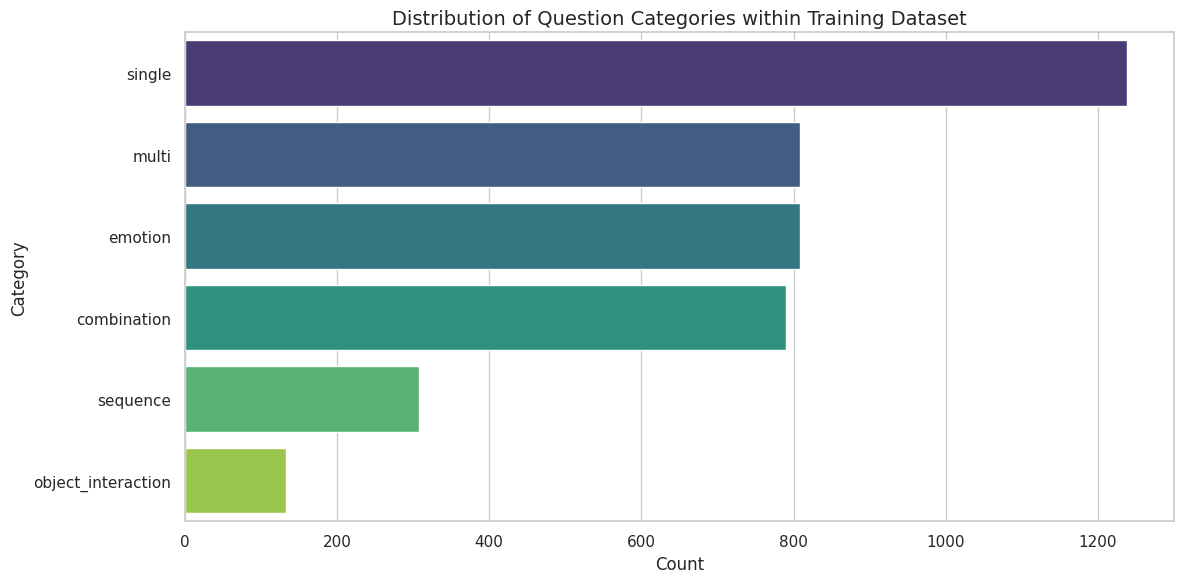

In [6]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

plt.figure(figsize=(12, 6))
sns.countplot(data=train_df, y='category', order=train_df['category'].value_counts().index, palette='viridis')
plt.title('Distribution of Question Categories within Training Dataset')
plt.xlabel('Count')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

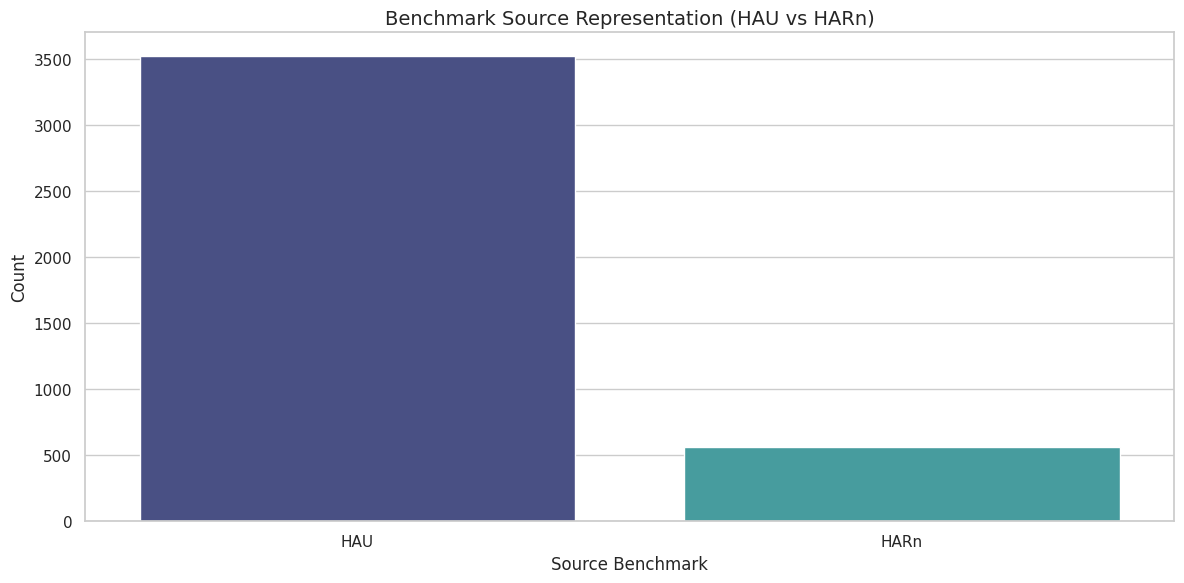

In [7]:
plt.figure(figsize=(12, 6))
sns.countplot(data=train_df, x='source', palette='mako')
plt.title('Benchmark Source Representation (HAU vs HARn)')
plt.xlabel('Source Benchmark')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

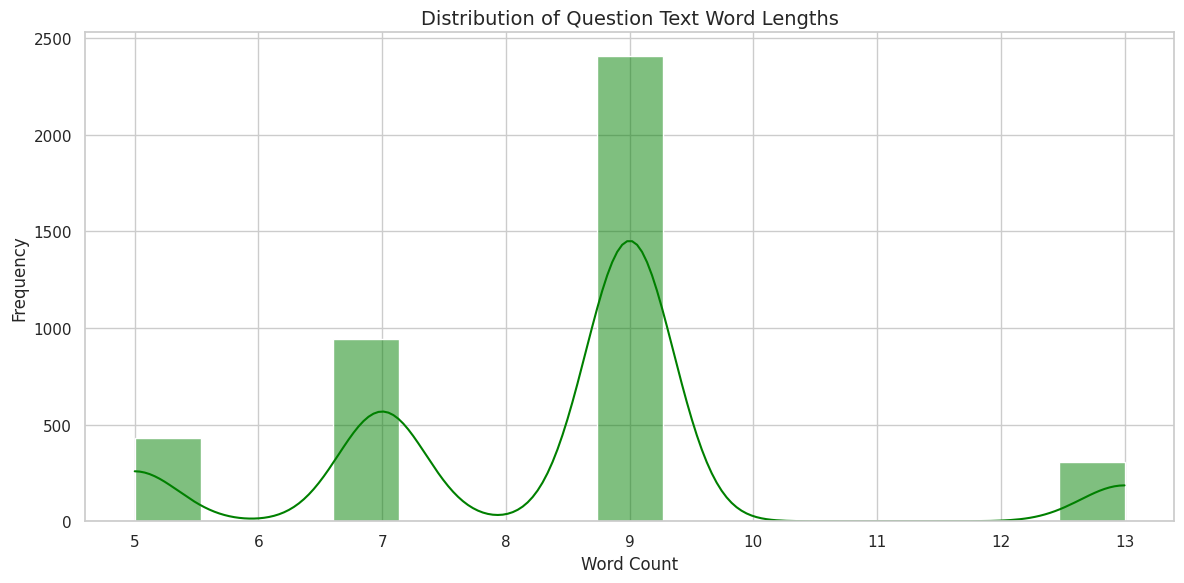

In [8]:
plt.figure(figsize=(12, 6))
train_df['question_len'] = train_df['question'].apply(lambda x: len(str(x).split()))
sns.histplot(data=train_df, x='question_len', kde=True, color='green', bins=15)
plt.title('Distribution of Question Text Word Lengths')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

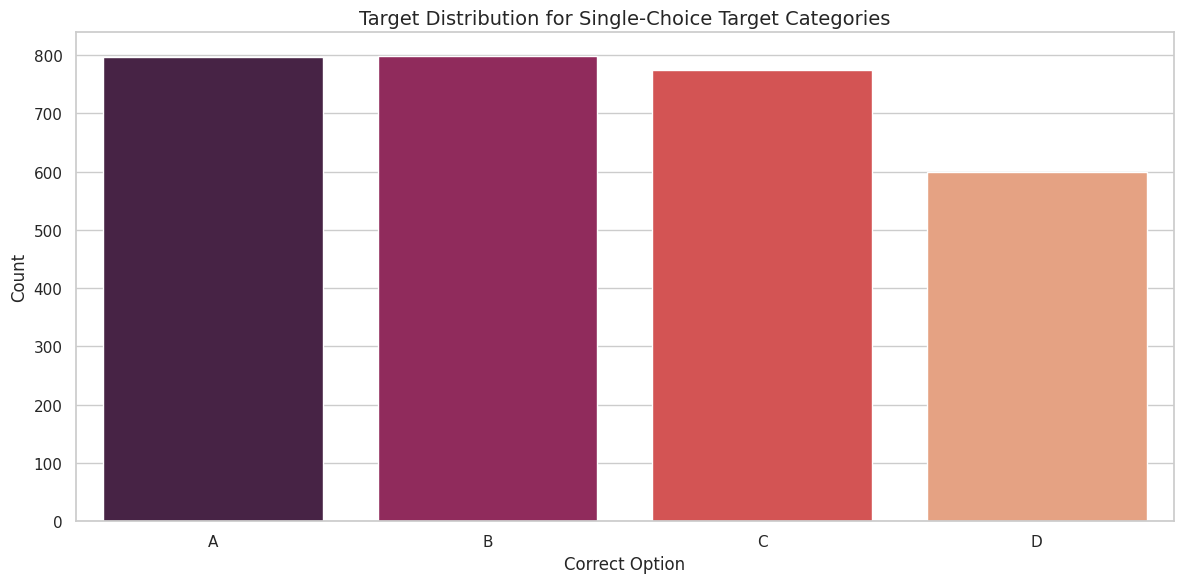

In [9]:
plt.figure(figsize=(12, 6))
single_choice_df = train_df[train_df['category'].isin(['single', 'combination', 'emotion', 'object_interaction'])]
sns.countplot(data=single_choice_df, x='answer', order=['A', 'B', 'C', 'D'], palette='rocket')
plt.title('Target Distribution for Single-Choice Target Categories')
plt.xlabel('Correct Option')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Advanced Mapping and Target Processing Architecture

Converting multi-format categorical answers into multi-task target matrices suitable for neural network backpropagation.

In [10]:
PERMUTATIONS = [''.join(p) for p in itertools.permutations('ABCD')]
perm_to_idx = {p: i for i, p in enumerate(PERMUTATIONS)}
idx_to_perm = {i: p for i, p in enumerate(PERMUTATIONS)}

print(f"Total unique temporal sequence permutations mapped: {len(PERMUTATIONS)}")

def map_category_group(cat_str):
    if cat_str in ['single', 'combination', 'emotion', 'object_interaction']:
        return 0
    elif cat_str == 'multi':
        return 1
    elif cat_str == 'sequence':
        return 2
    return 0

train_df['category_group'] = train_df['category'].apply(map_category_group)
test_df['category_group'] = test_df['category'].apply(map_category_group)

def encode_targets(df):
    targets_single = []
    targets_multi = []
    targets_seq = []
    
    label_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3}
    
    for _, row in df.iterrows():
        cat_g = row['category_group']
        ans = str(row['answer']).strip()
        
        t_s = 0
        t_m = [0.0, 0.0, 0.0, 0.0]
        t_q = 0
        
        if cat_g == 0:
            t_s = label_map.get(ans[0], 0) if len(ans) > 0 else 0
        elif cat_g == 1:
            for char in ans:
                if char in label_map:
                    t_m[label_map[char]] = 1.0
        elif cat_g == 2:
            t_q = perm_to_idx.get(ans, 0)
            
        targets_single.append(t_s)
        targets_multi.append(t_m)
        targets_seq.append(t_q)
        
    return np.array(targets_single), np.array(targets_multi), np.array(targets_seq)

t_single, t_multi, t_seq = encode_targets(train_df)
print("Targets successfully encoded into mathematical tensors.")

Total unique temporal sequence permutations mapped: 24
Targets successfully encoded into mathematical tensors.


# Contextual Text Compilation Strategy

Constructing dense context prompts mapping all problem metadata, questions, and respective choice combinations into a unified sequence string.

In [11]:
def build_context_string(df):
    contexts = []
    for _, row in df.iterrows():
        ctx = (f"Benchmark Source: {row['source']} | "
               f"Task Category: {row['category']} | "
               f"Question Context: {row['question']} | "
               f"Option A: {row['A']} | "
               f"Option B: {row['B']} | "
               f"Option C: {row['C']} | "
               f"Option D: {row['D']}")
        contexts.append(ctx)
    return contexts

train_df['context_text'] = build_context_string(train_df)
test_df['context_text'] = build_context_string(test_df)
print("Sample Context String Construction:")
print(train_df['context_text'].iloc[0])

Sample Context String Construction:
Benchmark Source: HAU | Task Category: single | Question Context: Which action is performed in this video? | Option A: Jumping jacks | Option B: Checking the time | Option C: Stirring | Option D: Brushing teeth


# Advanced Text Feature Extraction Pipeline via Pre-trained Transformer

Extracting semantic embedding vectors via an optimized sequence transformer network. Execution uses batch execution mechanics on the GPU device.

In [12]:
import transformers

transformers.logging.set_verbosity_error()

MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
transformer_encoder = AutoModel.from_pretrained(MODEL_NAME).to(device)

if num_gpus > 1:
    transformer_encoder = nn.DataParallel(transformer_encoder)

def extract_embeddings(text_list, batch_size=64):
    transformer_encoder.eval()
    all_embeddings = []
    
    for i in range(0, len(text_list), batch_size):
        batch_texts = text_list[i:i+batch_size]
        inputs = tokenizer(batch_texts, padding=True, truncation=True, max_length=128, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        with torch.no_grad():
            outputs = transformer_encoder(**inputs)
            # Extract CLS token vector
            if num_gpus > 1:
                embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            else:
                embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(embeddings)
        
    return np.vstack(all_embeddings)

print("Extracting training embeddings...")
train_embeddings = extract_embeddings(train_df['context_text'].tolist())
print("Extracting testing embeddings...")
test_embeddings = extract_embeddings(test_df['context_text'].tolist())

print(f"Train Embeddings shape: {train_embeddings.shape}")
print(f"Test Embeddings shape: {test_embeddings.shape}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Extracting training embeddings...
Extracting testing embeddings...
Train Embeddings shape: (4087, 768)
Test Embeddings shape: (682, 768)


# Custom Multi-Head Neural Network Architecture

Designing a modern deep neural network equipped with target tasks mapping to dedicated prediction modules.

In [13]:
class CUHKXMultiHeadNetwork(nn.Module):
    def __init__(self, input_dim=768):
        super().__init__()
        self.shared_backbone = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        # Classification Head: Single option prediction (A, B, C, D)
        self.head_single = nn.Linear(256, 4)
        
        # Multi-Label Head: Multi-action prediction selection
        self.head_multi = nn.Linear(256, 4)
        
        # Sequence Head: Chronological order permutation mapping
        self.head_sequence = nn.Linear(256, 24)
        
    def forward(self, x):
        features = self.shared_backbone(x)
        out_single = self.head_single(features)
        out_multi = self.head_multi(features)
        out_sequence = self.head_sequence(features)
        return out_single, out_multi, out_sequence

# PyTorch Dataset Definition

Constructing standard dataset loaders to stream features, groups, and labels to the training loops.

In [14]:
class CUHKXDataset(Dataset):
    def __init__(self, embeddings, cat_groups, t_s, t_m, t_q):
        self.embeddings = torch.tensor(embeddings, dtype=torch.float32)
        self.cat_groups = torch.tensor(cat_groups, dtype=torch.long)
        self.t_s = torch.tensor(t_s, dtype=torch.long)
        self.t_m = torch.tensor(t_m, dtype=torch.float32)
        self.t_q = torch.tensor(t_q, dtype=torch.long)
        
    def __len__(self):
        return len(self.embeddings)
        
    def __getitem__(self, idx):
        return (
            self.embeddings[idx],
            self.cat_groups[idx],
            self.t_s[idx],
            self.t_m[idx],
            self.t_q[idx]
        )

# Stratified Multi-Task Cross-Validation and Training Engine

Executing an out-of-fold validation loop using multi-gpu optimization, gradient scaling precision, and category masking algorithms.

In [15]:
N_SPLITS = 5
EPOCHS = 25
BATCH_SIZE = 64
LEARNING_RATE = 1e-3

strat_col = train_df['category'].astype(str) + "_" + train_df['source'].astype(str)
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

criterion_ce = nn.CrossEntropyLoss()
criterion_bce = nn.BCEWithLogitsLoss()

oof_preds_single = np.zeros((len(train_df), 4))
oof_preds_multi = np.zeros((len(train_df), 4))
oof_preds_seq = np.zeros((len(train_df), 24))

test_preds_single = np.zeros((len(test_df), 4))
test_preds_multi = np.zeros((len(test_df), 4))
test_preds_seq = np.zeros((len(test_df), 24))

cat_groups_arr = train_df['category_group'].values
test_cat_groups = test_df['category_group'].values

In [16]:
for fold, (train_idx, val_idx) in enumerate(skf.split(train_embeddings, strat_col)):
    print(f"\n--- Starting Optimization Loop for Cross Validation Fold {fold + 1} / {N_SPLITS} ---")
    
    train_ds = CUHKXDataset(train_embeddings[train_idx], cat_groups_arr[train_idx], t_single[train_idx], t_multi[train_idx], t_seq[train_idx])
    val_ds = CUHKXDataset(train_embeddings[val_idx], cat_groups_arr[val_idx], t_single[val_idx], t_multi[val_idx], t_seq[val_idx])
    
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    
    model = CUHKXMultiHeadNetwork(input_dim=train_embeddings.shape[1]).to(device)
    if num_gpus > 1:
        model = nn.DataParallel(model)
        
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    scaler = GradScaler()
    
    best_val_loss = float('inf')
    
    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        
        for embeds, groups, target_s, target_m, target_q in train_loader:
            embeds = embeds.to(device)
            groups = groups.to(device)
            target_s = target_s.to(device)
            target_m = target_m.to(device)
            target_q = target_q.to(device)
            
            optimizer.zero_grad()
            
            with autocast():
                out_s, out_m, out_q = model(embeds)
                
                loss = 0.0
                mask_s = (groups == 0)
                mask_m = (groups == 1)
                mask_q = (groups == 2)
                
                if mask_s.sum() > 0:
                    loss += criterion_ce(out_s[mask_s], target_s[mask_s])
                if mask_m.sum() > 0:
                    loss += criterion_bce(out_m[mask_m], target_m[mask_m])
                if mask_q.sum() > 0:
                    loss += criterion_ce(out_q[mask_q], target_q[mask_q])
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            running_loss += loss.item() * embeds.size(0)
            
        scheduler.step()
        
        # Validation Phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for embeds, groups, target_s, target_m, target_q in val_loader:
                embeds = embeds.to(device)
                groups = groups.to(device)
                target_s = target_s.to(device)
                target_m = target_m.to(device)
                target_q = target_q.to(device)
                
                out_s, out_m, out_q = model(embeds)
                
                loss = 0.0
                mask_s = (groups == 0)
                mask_m = (groups == 1)
                mask_q = (groups == 2)
                
                if mask_s.sum() > 0:
                    loss += criterion_ce(out_s[mask_s], target_s[mask_s])
                if mask_m.sum() > 0:
                    loss += criterion_bce(out_m[mask_m], target_m[mask_m])
                if mask_q.sum() > 0:
                    loss += criterion_ce(out_q[mask_q], target_q[mask_q])
                    
                val_loss += loss.item() * embeds.size(0)
                
        total_train_loss = running_loss / len(train_idx)
        total_val_loss = val_loss / len(val_idx)
        
        if total_val_loss < best_val_loss:
            best_val_loss = total_val_loss
            torch.save(model.state_dict(), f"best_model_fold_{fold}.pth")
            
    print(f"Fold {fold + 1} Complete. Optimal Validation Loss: {best_val_loss:.4f}")
    
    # Extract OOF Predictions
    best_model = CUHKXMultiHeadNetwork(input_dim=train_embeddings.shape[1]).to(device)
    if num_gpus > 1:
        best_model = nn.DataParallel(best_model)
    best_model.load_state_dict(torch.load(f"best_model_fold_{fold}.pth"))
    best_model.eval()
    
    with torch.no_grad():
        val_tensors = torch.tensor(train_embeddings[val_idx], dtype=torch.float32).to(device)
        o_s, o_m, o_q = best_model(val_tensors)
        oof_preds_single[val_idx] = torch.softmax(o_s, dim=1).cpu().numpy()
        oof_preds_multi[val_idx] = torch.sigmoid(o_m).cpu().numpy()
        oof_preds_seq[val_idx] = torch.softmax(o_q, dim=1).cpu().numpy()
        
        test_tensors = torch.tensor(test_embeddings, dtype=torch.float32).to(device)
        t_s, t_m, t_q = best_model(test_tensors)
        test_preds_single += torch.softmax(t_s, dim=1).cpu().numpy() / N_SPLITS
        test_preds_multi += torch.sigmoid(t_m).cpu().numpy() / N_SPLITS
        test_preds_seq += torch.softmax(t_q, dim=1).cpu().numpy() / N_SPLITS

print("Training process executed successfully across all validation splits.")


--- Starting Optimization Loop for Cross Validation Fold 1 / 5 ---
Fold 1 Complete. Optimal Validation Loss: 1.8646

--- Starting Optimization Loop for Cross Validation Fold 2 / 5 ---
Fold 2 Complete. Optimal Validation Loss: 1.8894

--- Starting Optimization Loop for Cross Validation Fold 3 / 5 ---
Fold 3 Complete. Optimal Validation Loss: 1.8817

--- Starting Optimization Loop for Cross Validation Fold 4 / 5 ---
Fold 4 Complete. Optimal Validation Loss: 1.8662

--- Starting Optimization Loop for Cross Validation Fold 5 / 5 ---
Fold 5 Complete. Optimal Validation Loss: 1.8628
Training process executed successfully across all validation splits.


# Validation Evaluation Metrics

Computing structural performance scores on the out-of-fold metrics across task categories.

In [17]:
oof_final_predictions = []
label_letters = ['A', 'B', 'C', 'D']

for idx, row in train_df.iterrows():
    cat_g = row['category_group']
    
    if cat_g == 0:
        pred_letter = label_letters[np.argmax(oof_preds_single[idx])]
        oof_final_predictions.append(pred_letter)
    elif cat_g == 1:
        probs = oof_preds_multi[idx]
        selected = [label_letters[i] for i in range(4) if probs[i] >= 0.5]
        if not selected:
            selected = [label_letters[np.argmax(probs)]]
        oof_final_predictions.append(''.join(selected))
    elif cat_g == 2:
        pred_seq_idx = np.argmax(oof_preds_seq[idx])
        oof_final_predictions.append(idx_to_perm[pred_seq_idx])

train_df['oof_prediction'] = oof_final_predictions
overall_accuracy = accuracy_score(train_df['answer'], train_df['oof_prediction'])
print(f"Overall Out-of-Fold Cross-Validation Accuracy score: {overall_accuracy:.4f}")

Overall Out-of-Fold Cross-Validation Accuracy score: 0.2263


# Test Set Inference and Submission Processing Layer

Compiling out-of-fold metrics onto test structures to build formatted submission targets matching the benchmark rules.

In [18]:
test_final_predictions = []

for idx, row in test_df.iterrows():
    cat_g = row['category_group']
    
    if cat_g == 0:
        pred_letter = label_letters[np.argmax(test_preds_single[idx])]
        test_final_predictions.append(pred_letter)
    elif cat_g == 1:
        probs = test_preds_multi[idx]
        selected = [label_letters[i] for i in range(4) if probs[i] >= 0.5]
        if not selected:
            selected = [label_letters[np.argmax(probs)]]
        test_final_predictions.append(''.join(selected))
    elif cat_g == 2:
        pred_seq_idx = np.argmax(test_preds_seq[idx])
        test_final_predictions.append(idx_to_perm[pred_seq_idx])

submission_df = pd.DataFrame({
    'qa_id': test_df['qa_id'],
    'prediction': test_final_predictions
})

submission_df.to_csv('submission.csv', index=False)
print("Submission compilation complete. File saved to disk as submission.csv.")

Submission compilation complete. File saved to disk as submission.csv.


In [19]:
print("Submission Data Head:")
display(submission_df.head(10))
print("\nDistribution of Predicted Values:")
print(submission_df['prediction'].value_counts())

Submission Data Head:


,qa_id,prediction
0,test_0001,A
1,test_0002,B
2,test_0003,B
3,test_0004,C
4,test_0005,B
5,test_0006,B
6,test_0007,D
7,test_0008,A
8,test_0009,C
9,test_0010,C



Distribution of Predicted Values:
prediction
B       221
C       199
A       187
D        36
DBCA     23
ABDC      8
BACD      7
ADBC      1
Name: count, dtype: int64


## Final Prediction Analysis and Outputs Verification

Placeholder section for post-execution validation mapping and out-of-fold performance analysis checks.